In [36]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [37]:
citra1 = cv.imread('assets/citra1.PNG')
citra2 = cv.imread('assets/citra2.PNG')

Text(0.5, 1.0, 'Citra 2')

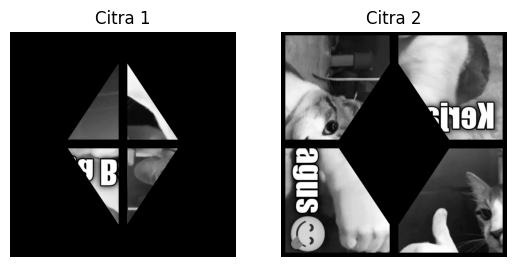

In [38]:
plt.subplot(1, 2, 1)
plt.imshow(citra1)
plt.axis('off')
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(citra2)
plt.axis('off')
plt.title('Citra 2')

In [39]:
gray1 = cv.cvtColor(citra1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(citra2, cv.COLOR_BGR2GRAY)

Text(0.5, 1.0, 'Citra 2')

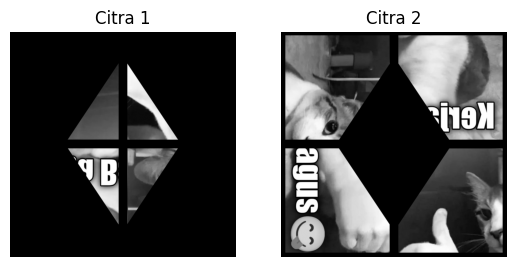

In [40]:
plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap = "gray")
plt.axis('off')
plt.title('Citra 1')

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap = "gray")
plt.axis('off')
plt.title('Citra 2')

In [41]:
def Rotasi(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0: return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[j, h - 1 - i] = image[i, j]
        return rot
    elif val == 180:
        rot = np.zeros((h, w), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j]
        return rot
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[w - 1 - j, i] = image[i, j]
        return rot
    return image

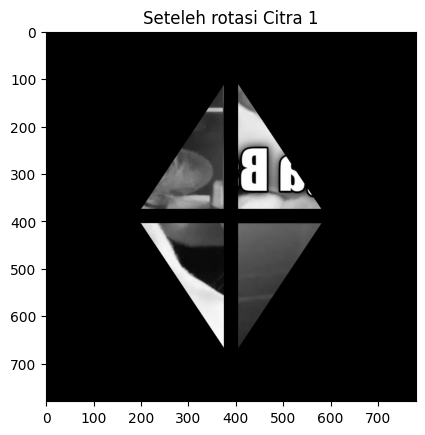

In [42]:
rotasiawal = Rotasi(gray1, 180)

plt.imshow(rotasiawal, cmap='gray')
plt.title("Seteleh rotasi Citra 1")
plt.show()

In [43]:
def Gabung(citra1, citra2):
    return citra1 + citra2

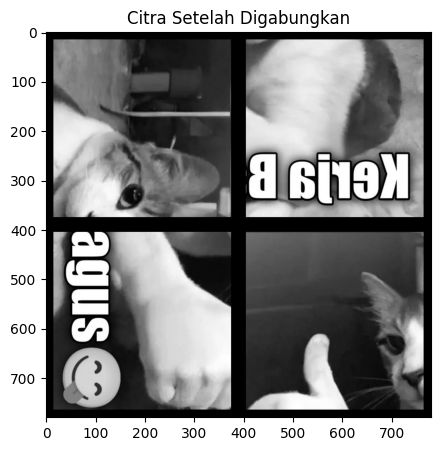

In [44]:
mergeAwal = Gabung(rotasiawal, gray2)

plt.figure(figsize=(6, 5))
plt.imshow(mergeAwal, cmap = 'gray')
plt.title('Citra Setelah Digabungkan')
plt.show()

In [45]:
def Slicing(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

In [46]:
potongKiri = Slicing(mergeAwal, 0, 399, 'V')
kiriA = Slicing(potongKiri, 0, 399, 'H')
kiriB = Slicing(potongKiri, 399, 800, 'H')
potongKanan = Slicing(mergeAwal, 399, 800, 'V')
kananA = Slicing(potongKanan, 0, 399, 'H')
kananB = Slicing(potongKanan, 399, 800, 'H')

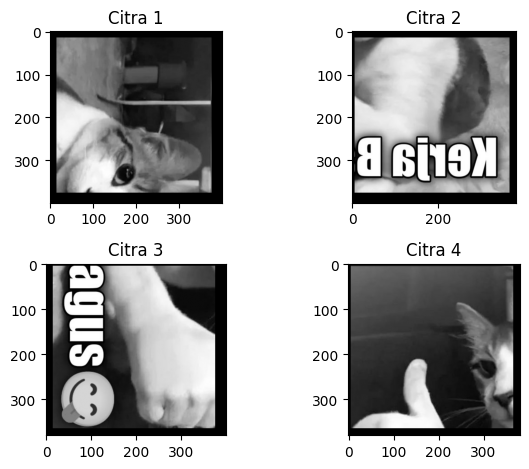

In [49]:
plt.subplot(2, 2, 1)
plt.imshow(kiriA, cmap = "gray")
plt.title('Citra 1')

plt.subplot(2, 2, 2)
plt.imshow(kananA, cmap = "gray")
plt.title('Citra 2')

plt.subplot(2, 2, 3)
plt.imshow(kiriB, cmap = "gray")
plt.title('Citra 3')

plt.subplot(2, 2, 4)
plt.imshow(kananB, cmap = "gray")
plt.title('Citra 4')
plt.tight_layout()
plt.show()

In [50]:
def Flipping(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[h - 1 - i, j]
            elif mode == 'Y':
                hasil[i, j] = image[i, w - 1 - j]
    return hasil

In [ ]:
flippingCitra2 = Flipping(kananA, 'Y')
flippingCitra4 = Flipping(kananB, 'X')